<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/EDA_Functions_and_Inspecting_Features_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**2.1) What data have we been provided?**

In [2]:
# Import packages
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
# Setting the max_columns to 50
pd.set_option('display.max_columns',50)
# Find the file on the sidebar and copy path
fpath = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week04/ames-housing-dojo.csv"

#**2.2)What information is included in the data?**

In [3]:
# Read in the data and display the preview/summary
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2959 entries, 0 to 2958
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2959 non-null   int64  
 1   PID             2959 non-null   int64  
 2   MS Zoning       2959 non-null   object 
 3   Lot Frontage    2959 non-null   int64  
 4   Lot Area        2959 non-null   int64  
 5   Street          2959 non-null   object 
 6   Alley           201 non-null    object 
 7   Utilities       2959 non-null   object 
 8   Neighborhood    2959 non-null   object 
 9   Bldg Type       2959 non-null   object 
 10  House Style     2959 non-null   object 
 11  Overall Qual    2959 non-null   int64  
 12  Overall Cond    2959 non-null   int64  
 13  Year Built      2959 non-null   int64  
 14  Year Remod/Add  2959 non-null   int64  
 15  Exter Qual      2959 non-null   object 
 16  Exter Cond      2959 non-null   object 
 17  Bsmt Unf SF     2958 non-null   f

,Unnamed: 0,PID,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Exter Qual,Exter Cond,Bsmt Unf SF,Total Bsmt SF,Central Air,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,TotRms AbvGrd,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice
0,0,907227090,RL,60,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864sqft,0.0,0.0,1,0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,03-2006,119900.0
1,1,527108010,RL,134,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462sqft,1.0,0.0,2,1,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,03-2006,320000.0
2,2,534275170,RL,-1,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958sqft,0.0,0.0,1,0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,04-2007,151500.0
3,3,528104050,RL,114,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084sqft,1.0,0.0,2,0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,06-2008,385000.0
4,4,533206070,FV,32,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565sqft,1.0,0.0,2,0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,02-2007,193800.0


**How many features (columns)? How many records (rows)?**

The file had 2,959 rows and 38 columns.
What is each feature's format/data type (string/integer/etc.)?

**There was a mixture of datatypes:**

8 float
12 int
18 object

In [4]:
# We then checked for any object columns that needed to be converted to a numeric type.
# Checking object columns for numeric data
df.select_dtypes('object').head()

,MS Zoning,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Exter Qual,Exter Cond,Central Air,Gr Liv Area,Half Bath,Garage Type,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold
0,RL,Pave,NaN,AllPub,CollgCr,1Fam,1Story,TA,TA,Y,864sqft,0,Detchd,TA,TA,Y,MnPrv,03-2006
1,RL,Pave,NaN,AllPub,Gilbert,1Fam,2Story,Gd,TA,Y,2462sqft,1,Attchd,TA,TA,Y,NaN,03-2006
2,RL,Pave,NaN,AllPub,NAmes,1Fam,1Story,TA,Gd,Y,958sqft,0,Attchd,TA,TA,Y,NaN,04-2007
3,RL,Pave,NaN,AllPub,NridgHt,1Fam,1Story,Ex,TA,Y,2084sqft,0,Attchd,TA,TA,Y,NaN,06-2008
4,FV,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,Gd,TA,Y,1565sqft,0,Attchd,TA,TA,Y,NaN,02-2007


#**Fix and Convert "Gr Liv Area"**

In [5]:
# "Gr Liv Area" is supposed to be numeric but had "sqft" added to every value.
# Replace sqft with nothing
df['Gr Liv Area'] = df['Gr Liv Area'].str.replace("sqft",'')
df['Gr Liv Area'] = df['Gr Liv Area'].astype(float)
# Preview the first 5 values for the column to verify the change
df['Gr Liv Area'].head()

,Gr Liv Area
0,864.0
1,2462.0
2,958.0
3,2084.0
4,1565.0


#**Fix and Convert "Half Bath"**

In [6]:
# Check value counts
df['Half Bath'].value_counts(dropna=False)

,count
Half Bath,
0,1855
1,1076
2,25
?,3


#**Replace the null values using np.nan.**

In [7]:
# Replace ? with null Nan for ML
df['Half Bath'] = df['Half Bath'].replace('?', np.nan)
# Check value counts
df['Half Bath'].value_counts(dropna=False)

,count
Half Bath,
0,1855
1,1076
2,25
NaN,3


In [8]:
# Now we can convert the column to a float.
# Convert the column to a float
df['Half Bath'] = df['Half Bath'].astype(float)
# Confirm the data type of the column
df['Half Bath'].head()

,Half Bath
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0


#**Drop An "Unnamed: 0" column**

In [9]:
# Dropping unnamed 0 (permanently)
df = df.drop(columns=['Unnamed: 0'])
df.head()

,PID,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Exter Qual,Exter Cond,Bsmt Unf SF,Total Bsmt SF,Central Air,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,TotRms AbvGrd,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice
0,907227090,RL,60,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,0.0,0.0,1,0.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,03-2006,119900.0
1,527108010,RL,134,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,1.0,0.0,2,1.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,03-2006,320000.0
2,534275170,RL,-1,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,0.0,0.0,1,0.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,04-2007,151500.0
3,528104050,RL,114,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,1.0,0.0,2,0.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,06-2008,385000.0
4,533206070,FV,32,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,1.0,0.0,2,0.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,02-2007,193800.0


**What is the meaning of each feature (how does it relate to the stakeholder’s goals?)**

**Rename columns**

In [10]:
# Create a dictionary using old column name : new column name format
rename_dict = {"Year Remod/Add":"Year Remodeled",
               "Bsmt Unf SF": "Bsmt Unf Sqft",
               "Total Bsmt SF": "Total Bsmnt Sqft",
               "TotRms AbvGrd": "Total Rooms",
               "Gr Liv Area":"Living Area Sqft"}
# dictionary substitution using rename method
df = df.rename(rename_dict,axis=1)
df.head()

,PID,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice
0,907227090,RL,60,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,0.0,0.0,1,0.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,03-2006,119900.0
1,527108010,RL,134,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,1.0,0.0,2,1.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,03-2006,320000.0
2,534275170,RL,-1,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,0.0,0.0,1,0.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,04-2007,151500.0
3,528104050,RL,114,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,1.0,0.0,2,0.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,06-2008,385000.0
4,533206070,FV,32,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,1.0,0.0,2,0.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,02-2007,193800.0


#**Are there duplicate rows?**

In [11]:
# Check for exact duplicates (all columns)
df.duplicated().sum()

np.int64(7)

In [12]:
# Drop exact duplicates
df = df.drop_duplicates()
# Confirm no more duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# How many rows are duplicates (including the first occurence)
duplicated_pids = df.duplicated(subset=['PID'], keep=False)
# Visually checking the duplicate rows
df[duplicated_pids].sort_values("PID").head()

,PID,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice
1650,526355080,RL,75,13860,Pave,NaN,AllPub,NAmes,1Fam,SLvl,8,7,1972,1995,Gd,TA,542.0,1952.0,Y,2704.0,1.0,0.0,2,1.0,4,1,9,Attchd,1972.0,2.0,538.0,TA,TA,Y,MnPrv,07-2009,345000.0
2654,526355080,RL,75,13860,Pave,NaN,AllPub,NAmes,1Fam,SLvl,8,7,1972,1995,Gd,TA,542.0,1952.0,Y,2704.0,1.0,0.0,2,1.0,4,1,9,Attchd,1972.0,2.0,538.0,TA,TA,Y,MnPrv,07-2009,NaN
2469,527110020,RL,-1,8530,Pave,NaN,AllPub,Gilbert,1Fam,SLvl,7,5,1995,1996,TA,TA,384.0,384.0,Y,1474.0,0.0,0.0,2,1.0,3,1,7,BuiltIn,1995.0,2.0,400.0,TA,TA,Y,NaN,05-2009,NaN
135,527110020,RL,-1,8530,Pave,NaN,AllPub,Gilbert,1Fam,SLvl,7,5,1995,1996,TA,TA,384.0,384.0,Y,1474.0,0.0,0.0,2,1.0,3,1,7,BuiltIn,1995.0,2.0,400.0,TA,TA,Y,NaN,05-2009,168500.0
626,527326040,RL,85,11900,Pave,NaN,AllPub,NWAmes,1Fam,1Story,7,5,1977,1977,TA,Gd,564.0,1386.0,Y,1411.0,0.0,0.0,2,0.0,3,1,6,Attchd,1977.0,2.0,544.0,TA,TA,Y,NaN,04-2009,82500.0


In [14]:
# Dropping Null values from SalePrice
df = df.dropna(subset=["SalePrice"])
# Confirming no more null sale prices
df['SalePrice'].isna().sum()

np.int64(0)

In [15]:
# Confirming  no more duplicated PIDs
df.duplicated(subset=['PID'], keep=False).sum()

np.int64(0)

In [16]:
# Checking if PID is 100% unique
df['PID'].nunique()/len(df)* 100

100.0

#**Setting the Index**

In [17]:
# Making PID the index
df = df.set_index("PID")
df.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
907227090,RL,60,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,0.0,0.0,1,0.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,03-2006,119900.0
527108010,RL,134,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,1.0,0.0,2,1.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,03-2006,320000.0
534275170,RL,-1,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,0.0,0.0,1,0.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,04-2007,151500.0
528104050,RL,114,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,1.0,0.0,2,0.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,06-2008,385000.0
533206070,FV,32,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,1.0,0.0,2,0.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,02-2007,193800.0


#**Are there missing values?**

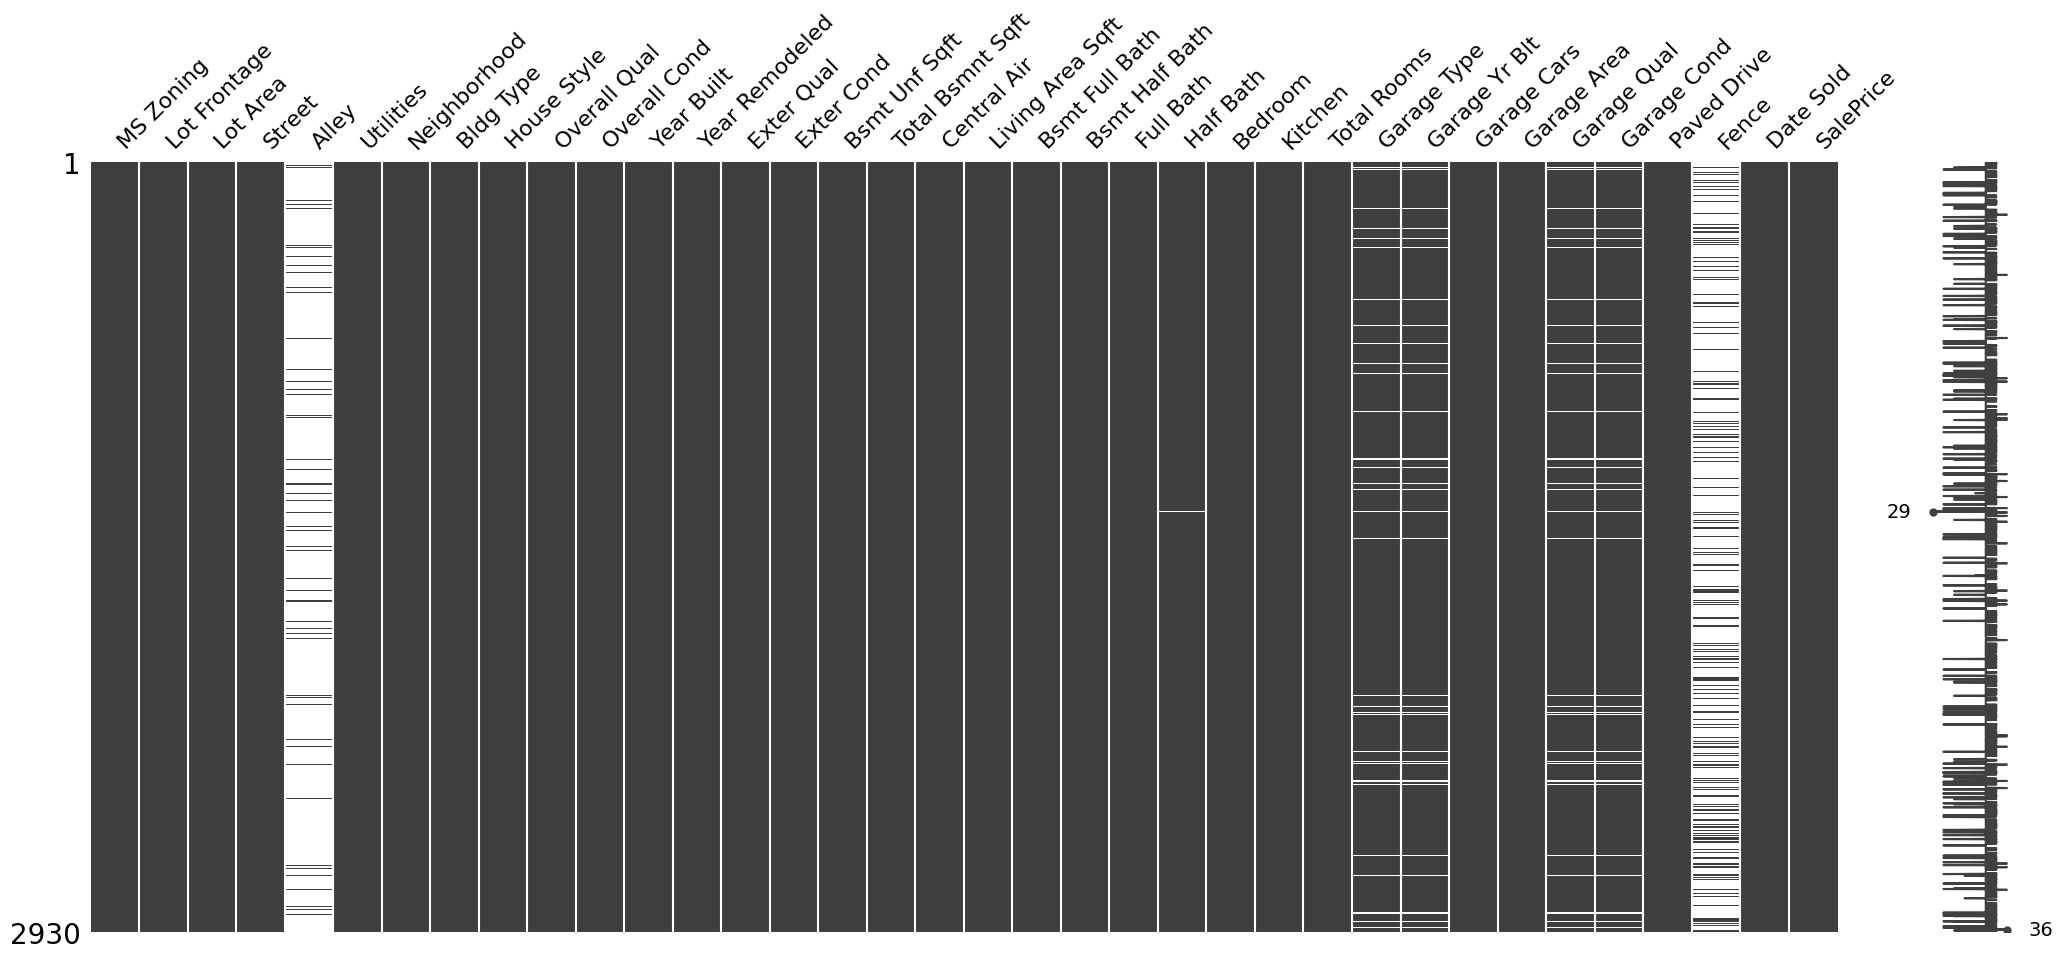

In [18]:
# Using missingno to view heatmap of NaN's
msno.matrix(df);

In [19]:
# Get the # of null values per column
null_sums = df.isna().sum()
null_sums[null_sums>0]

,0
Alley,2732
Bsmt Unf Sqft,1
Total Bsmnt Sqft,1
Bsmt Full Bath,2
Bsmt Half Bath,2
Half Bath,3
Garage Type,157
Garage Yr Blt,159
Garage Cars,1
Garage Area,1


In [20]:
# Calculate the % of null values
null_percent = null_sums/len(df) * 100
# Show only columns with missing values
null_percent[null_percent>0]


,0
Alley,93.242321
Bsmt Unf Sqft,0.034130
Total Bsmnt Sqft,0.034130
Bsmt Full Bath,0.068259
Bsmt Half Bath,0.068259
Half Bath,0.102389
Garage Type,5.358362
Garage Yr Blt,5.426621
Garage Cars,0.034130
Garage Area,0.034130


#**Are there any features with inconsistent values? (“yes” vs. “Yes”)**

In [21]:
# Identify string columns
string_cols = df.select_dtypes("object").columns
string_cols

Index(['MS Zoning', 'Street', 'Alley', 'Utilities', 'Neighborhood',
       'Bldg Type', 'House Style', 'Exter Qual', 'Exter Cond', 'Central Air',
       'Garage Type', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Fence',
       'Date Sold'],
      dtype='object')

In [22]:
# Obtain the value counts for all string columns
for col in string_cols:
  print(f"Value Counts for {col}")
  print(df[col].value_counts())
  # Increasing readability by adding an empty line
  print('\n')

Value Counts for MS Zoning
MS Zoning
RL         2273
RM          462
FV          139
RH           27
C (all)      25
I (all)       2
A (agr)       2
Name: count, dtype: int64


Value Counts for Street
Street
Pave    2918
Grvl      12
Name: count, dtype: int64


Value Counts for Alley
Alley
Grvl    120
Pave     78
Name: count, dtype: int64


Value Counts for Utilities
Utilities
AllPub    2927
NoSewr       2
NoSeWa       1
Name: count, dtype: int64


Value Counts for Neighborhood
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64


Value Counts for Bldg Type
Bldg Type
1Fam      2425
Twnh

#**Fixing Central Air**

In [23]:
# Check the unique values and counts of the 'Central Air' column
df['Central Air'].value_counts()

,count
Central Air,
Y,2697
N,191
yes,37
no,5


In [24]:
# Standardize the values in the Central column
df['Central Air'] = df['Central Air'].replace({'yes':"Y",'no':'N'})
df['Central Air'].value_counts()

,count
Central Air,
Y,2734
N,196


#**Are there any numeric features with inconsistent or impossible values?**

In [25]:
# Getting the description for numeric features
description = df.describe().round(2)
description

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remodeled,Bsmt Unf Sqft,Total Bsmnt Sqft,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Yr Blt,Garage Cars,Garage Area,SalePrice
count,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2929.00,2929.00,2930.00,2928.00,2928.00,2930.00,2927.00,2930.00,2930.00,2930.00,2771.00,2929.00,2929.00,2930.00
mean,57.48,10147.92,6.09,5.56,1971.36,1984.27,559.26,1051.61,1499.69,0.43,0.06,1.57,0.38,2.85,1.04,6.44,1978.13,1.77,472.82,181439.40
std,33.79,7880.02,1.41,1.11,30.25,20.86,439.49,440.62,505.51,0.52,0.25,0.55,0.50,0.83,0.21,1.57,25.53,0.76,215.05,86659.68
min,-1.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,334.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1895.00,0.00,0.00,12789.00
25%,43.00,7440.25,5.00,5.00,1954.00,1965.00,219.00,793.00,1126.00,0.00,0.00,1.00,0.00,2.00,1.00,5.00,1960.00,1.00,320.00,129500.00
50%,63.00,9436.50,6.00,5.00,1973.00,1993.00,466.00,990.00,1442.00,0.00,0.00,2.00,0.00,3.00,1.00,6.00,1979.00,2.00,480.00,160000.00
75%,78.00,11555.25,7.00,6.00,2001.00,2004.00,802.00,1302.00,1742.75,1.00,0.00,2.00,1.00,3.00,1.00,7.00,2002.00,2.00,576.00,213500.00
max,313.00,215245.00,10.00,9.00,2010.00,2010.00,2336.00,6110.00,5642.00,3.00,2.00,4.00,2.00,8.00,3.00,15.00,2207.00,5.00,1488.00,2000000.00


In [26]:
# Limit output to min, max, 25% and 75%
description.loc[['min','25%','75%','max']]

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remodeled,Bsmt Unf Sqft,Total Bsmnt Sqft,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Yr Blt,Garage Cars,Garage Area,SalePrice
min,-1.0,1300.00,1.0,1.0,1872.0,1950.0,0.0,0.0,334.00,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1895.0,0.0,0.0,12789.0
25%,43.0,7440.25,5.0,5.0,1954.0,1965.0,219.0,793.0,1126.00,0.0,0.0,1.0,0.0,2.0,1.0,5.0,1960.0,1.0,320.0,129500.0
75%,78.0,11555.25,7.0,6.0,2001.0,2004.0,802.0,1302.0,1742.75,1.0,0.0,2.0,1.0,3.0,1.0,7.0,2002.0,2.0,576.0,213500.0
max,313.0,215245.00,10.0,9.0,2010.0,2010.0,2336.0,6110.0,5642.00,3.0,2.0,4.0,2.0,8.0,3.0,15.0,2207.0,5.0,1488.0,2000000.0


#**Addressing Lot Frontage**

In [27]:
# How many rows with Lot Frontage -1's
filter_neg_lot_frontage = df['Lot Frontage'] < 0
filter_neg_lot_frontage.sum()

np.int64(490)

In [28]:
# Replacing negative lot frontages with null values
df.loc[filter_neg_lot_frontage,'Lot Frontage'] = np.nan
# Confirming no longer rows with Lot Frontage < 0
filter_neg_lot_frontage = df['Lot Frontage'] < 0
filter_neg_lot_frontage.sum()

np.int64(0)

#**Addressing Sale Price**

In [29]:
# Visualze expensive home (SalePrice >= 2 million)
filter_high_price = df['SalePrice'] >= 2_000_000
df[filter_high_price]

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
902201120,RM,50.0,6000,Pave,NaN,AllPub,OldTown,1Fam,1Story,5,5,1948,1950,TA,TA,516.0,789.0,Y,789.0,0.0,0.0,1,0.0,2,1,5,Detchd,1948.0,1.0,250.0,TA,TA,Y,NaN,04-2008,2000000.0


In [30]:
# Checking 5 highest prices to compare against outlier $2 million
df.sort_values("SalePrice", ascending=False).head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
902201120,RM,50.0,6000,Pave,NaN,AllPub,OldTown,1Fam,1Story,5,5,1948,1950,TA,TA,516.0,789.0,Y,789.0,0.0,0.0,1,0.0,2,1,5,Detchd,1948.0,1.0,250.0,TA,TA,Y,NaN,04-2008,2000000.0
528351010,RL,104.0,21535,Pave,NaN,AllPub,NoRidge,1Fam,2Story,10,6,1994,1995,Ex,TA,989.0,2444.0,Y,4316.0,0.0,1.0,3,1.0,4,1,10,Attchd,1994.0,3.0,832.0,TA,TA,Y,NaN,01-2007,755000.0
528320050,RL,160.0,15623,Pave,NaN,AllPub,NoRidge,1Fam,2Story,10,5,1996,1996,Gd,TA,300.0,2396.0,Y,4476.0,1.0,0.0,3,1.0,4,1,10,Attchd,1996.0,3.0,813.0,TA,TA,Y,MnPrv,07-2007,745000.0
528320060,RL,118.0,35760,Pave,NaN,AllPub,NoRidge,1Fam,2Story,10,5,1995,1996,Gd,Gd,543.0,1930.0,Y,3627.0,1.0,0.0,3,1.0,4,1,10,Attchd,1995.0,3.0,807.0,TA,TA,Y,NaN,07-2006,625000.0
528164060,RL,106.0,12720,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2003,2003,Ex,TA,278.0,2535.0,Y,2470.0,2.0,0.0,1,1.0,1,1,7,Attchd,2003.0,3.0,789.0,TA,TA,Y,NaN,02-2008,615000.0


In [31]:
# Replacing 2 million with 200,000
df.loc[filter_high_price,'SalePrice'] = 200_000
df['SalePrice'].describe()

,SalePrice
count,2930.000000
mean,180825.070307
std,79878.223965
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


#**Addressing Garage Yr Blt**

In [32]:
# Filter for row with Garage Yr Blt = 2207
filter_typo_garage_year = df['Garage Yr Blt'] == 2207
df.loc[filter_typo_garage_year,'Garage Yr Blt'] = np.nan
df['Garage Yr Blt'].describe()

,Garage Yr Blt
count,2770.000000
mean,1978.049819
std,25.159722
min,1895.000000
25%,1960.000000
50%,1979.000000
75%,2002.000000
max,2010.000000


#**Do any features need to be combined or separated?**

In [33]:
# Create two new columns based on the split by using expand = True
df[['Month','Year']] = df['Date Sold'].str.split('-', expand=True)
df.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,Date Sold,SalePrice,Month,Year
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,0.0,0.0,1,0.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,03-2006,119900.0,03,2006
527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,1.0,0.0,2,1.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,03-2006,320000.0,03,2006
534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,0.0,0.0,1,0.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,04-2007,151500.0,04,2007
528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,1.0,0.0,2,0.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,06-2008,385000.0,06,2008
533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,1.0,0.0,2,0.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,02-2007,193800.0,02,2007


In [34]:
# Dropping original column after confirming new features created
df = df.drop(columns=['Date Sold'])
df.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,SalePrice,Month,Year
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,0.0,0.0,1,0.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,119900.0,03,2006
527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,1.0,0.0,2,1.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,320000.0,03,2006
534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,0.0,0.0,1,0.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,151500.0,04,2007
528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,1.0,0.0,2,0.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,385000.0,06,2008
533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,1.0,0.0,2,0.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,193800.0,02,2007


#**Combine Half Bath and Bsmt Half Bath into Total Half Baths**

In [35]:
# Add values from two columns to create a new column
df['Total Half Baths'] = df['Half Bath']+ df['Bsmt Half Bath']
df['Total Half Baths'].head()

,Total Half Baths
PID,
907227090,0.0
527108010,1.0
534275170,0.0
528104050,0.0
533206070,0.0


In [36]:
# Drop the original columns
df = df.drop(columns=['Half Bath', 'Bsmt Half Bath'])
df.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bsmt Full Bath,Full Bath,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,SalePrice,Month,Year,Total Half Baths
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,0.0,1,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,119900.0,03,2006,0.0
527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,1.0,2,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,320000.0,03,2006,1.0
534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,0.0,1,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,151500.0,04,2007,0.0
528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,1.0,2,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,385000.0,06,2008,0.0
533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,1.0,2,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,193800.0,02,2007,0.0


#**Combine Full Bath and Bsmt Full Bath into Total Full Baths**

In [37]:
# Add values from two columns to create a new column
df['Total Full Baths'] = df['Full Bath'] + df['Bsmt Full Bath']
df['Total Full Baths'].head()

,Total Full Baths
PID,
907227090,1.0
527108010,3.0
534275170,1.0
528104050,3.0
533206070,3.0


In [38]:
# Drop the original columns
df = df.drop(columns=['Full Bath', 'Bsmt Full Bath'])
df.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,SalePrice,Month,Year,Total Half Baths,Total Full Baths
PID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,119900.0,03,2006,0.0,1.0
527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,320000.0,03,2006,1.0,3.0
534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,151500.0,04,2007,0.0,1.0
528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,385000.0,06,2008,0.0,3.0
533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,193800.0,02,2007,0.0,3.0


In [39]:
fpath_out = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week04/Data/ames-housing-for-ml.csv"
df.to_csv(fpath_out, index=True)

In [40]:
# Testing saved file
loaded = pd.read_csv(fpath_out)
loaded

,PID,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,SalePrice,Month,Year,Total Half Baths,Total Full Baths
0,907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,119900.0,3,2006,0.0,1.0
1,527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,320000.0,3,2006,1.0,3.0
2,534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,151500.0,4,2007,0.0,1.0
3,528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,385000.0,6,2008,0.0,3.0
4,533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,193800.0,2,2007,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,903400030,RL,50.0,11672,Pave,Pave,AllPub,BrkSide,1Fam,1Story,5,5,1925,1950,TA,TA,816.0,816.0,Y,816.0,2,1,4,Detchd,1925.0,1.0,210.0,Fa,Fa,N,NaN,109000.0,7,2006,0.0,1.0
2926,533234020,FV,79.0,10646,Pave,NaN,AllPub,Somerst,1Fam,2Story,7,5,2001,2001,TA,TA,177.0,858.0,Y,1789.0,3,1,7,Attchd,2001.0,2.0,546.0,TA,TA,Y,NaN,223000.0,6,2008,1.0,3.0
2927,908188140,RM,24.0,2522,Pave,NaN,AllPub,Edwards,Twnhs,2Story,7,5,2004,2004,Gd,TA,970.0,970.0,Y,1709.0,3,1,7,Detchd,2004.0,2.0,380.0,TA,TA,Y,NaN,137500.0,4,2006,0.0,2.0
2928,909254050,RL,54.0,7609,Pave,NaN,AllPub,Crawfor,1Fam,2Story,8,9,1925,1997,Gd,Gd,392.0,798.0,Y,1512.0,3,1,7,Detchd,1925.0,1.0,180.0,TA,TA,P,GdPrv,231000.0,6,2008,0.0,3.0


In [41]:
# Saving the final dataframe to Google Drive
fpath_out = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week04/Data/ames-housing-for-ml.csv"
df.to_csv(fpath_out, index=True)

# Testing saved file
loaded = pd.read_csv(fpath_out)
loaded

,PID,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Utilities,Neighborhood,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remodeled,Exter Qual,Exter Cond,Bsmt Unf Sqft,Total Bsmnt Sqft,Central Air,Living Area Sqft,Bedroom,Kitchen,Total Rooms,Garage Type,Garage Yr Blt,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Fence,SalePrice,Month,Year,Total Half Baths,Total Full Baths
0,907227090,RL,60.0,7200,Pave,NaN,AllPub,CollgCr,1Fam,1Story,5,8,1972,1972,TA,TA,427.0,864.0,Y,864.0,3,1,5,Detchd,1977.0,1.0,297.0,TA,TA,Y,MnPrv,119900.0,3,2006,0.0,1.0
1,527108010,RL,134.0,19378,Pave,NaN,AllPub,Gilbert,1Fam,2Story,7,5,2005,2006,Gd,TA,1335.0,1392.0,Y,2462.0,4,1,9,Attchd,2006.0,2.0,576.0,TA,TA,Y,NaN,320000.0,3,2006,1.0,3.0
2,534275170,RL,NaN,12772,Pave,NaN,AllPub,NAmes,1Fam,1Story,6,8,1960,1998,TA,Gd,460.0,958.0,Y,958.0,2,1,5,Attchd,1960.0,1.0,301.0,TA,TA,Y,NaN,151500.0,4,2007,0.0,1.0
3,528104050,RL,114.0,14803,Pave,NaN,AllPub,NridgHt,1Fam,1Story,10,5,2007,2008,Ex,TA,442.0,2078.0,Y,2084.0,2,1,7,Attchd,2007.0,3.0,1220.0,TA,TA,Y,NaN,385000.0,6,2008,0.0,3.0
4,533206070,FV,32.0,3784,Pave,Pave,AllPub,Somerst,TwnhsE,1Story,8,5,2006,2007,Gd,TA,1451.0,1511.0,Y,1565.0,2,1,5,Attchd,2006.0,2.0,476.0,TA,TA,Y,NaN,193800.0,2,2007,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,903400030,RL,50.0,11672,Pave,Pave,AllPub,BrkSide,1Fam,1Story,5,5,1925,1950,TA,TA,816.0,816.0,Y,816.0,2,1,4,Detchd,1925.0,1.0,210.0,Fa,Fa,N,NaN,109000.0,7,2006,0.0,1.0
2926,533234020,FV,79.0,10646,Pave,NaN,AllPub,Somerst,1Fam,2Story,7,5,2001,2001,TA,TA,177.0,858.0,Y,1789.0,3,1,7,Attchd,2001.0,2.0,546.0,TA,TA,Y,NaN,223000.0,6,2008,1.0,3.0
2927,908188140,RM,24.0,2522,Pave,NaN,AllPub,Edwards,Twnhs,2Story,7,5,2004,2004,Gd,TA,970.0,970.0,Y,1709.0,3,1,7,Detchd,2004.0,2.0,380.0,TA,TA,Y,NaN,137500.0,4,2006,0.0,2.0
2928,909254050,RL,54.0,7609,Pave,NaN,AllPub,Crawfor,1Fam,2Story,8,9,1925,1997,Gd,Gd,392.0,798.0,Y,1512.0,3,1,7,Detchd,1925.0,1.0,180.0,TA,TA,P,GdPrv,231000.0,6,2008,0.0,3.0


#**EDA Functions Part 1**

##**Make a Temporary Copy of the Dataframe for EDA**

In [42]:
# Copy of dataframe just for visualization and EDA
temp_df = df.copy()

##**Fill in missing values with a placeholder**

In [43]:
# Let's start with Alley
x = 'Alley'
placeholder = 'MISSING'
# In our temporatory df, we will fill in the missing values in the Alley column with the placeholder, MISSING
temp_df[x] = temp_df[x].fillna(placeholder)

##**Making a Countplot**

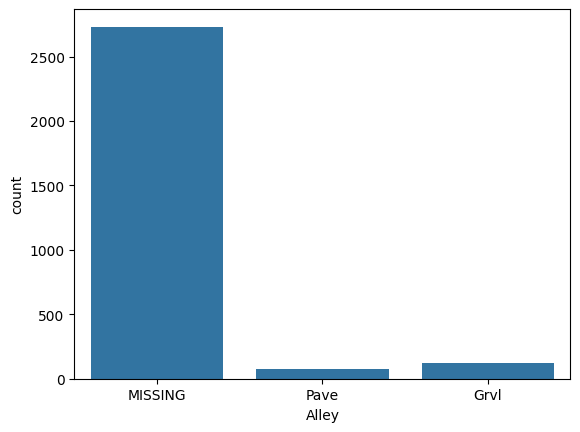

In [44]:
# Plotting a count plot
sns.countplot(data=temp_df, x=x);

##**Customize the Plot**

/tmp/ipykernel_720/2469339648.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


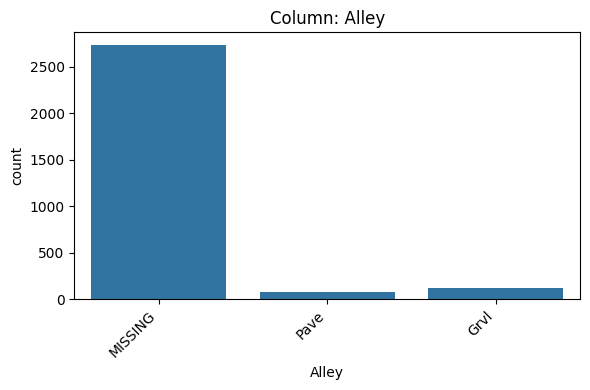

In [45]:
# Create figure with desired figsize
fig, ax = plt.subplots(figsize=(6,4))
# Plotting a count plot
sns.countplot(data=temp_df, x=x, ax=ax)
# Rotate Tick Labels for long names
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Add a title with the feature name included
ax.set_title(f"Column: {x}")
fig.tight_layout();

In [46]:
def explore_categorical(df, x, placeholder = 'MISSING'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy();
  # Fill in missing values with placeholder
  temp_df[x] = temp_df[x].fillna(placeholder);
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=(6,4))
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax);
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');
  # Add. atitle with the feature name included
  ax.set_title(f"Column: {x}");
  fig.tight_layout();

/tmp/ipykernel_720/3648891825.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


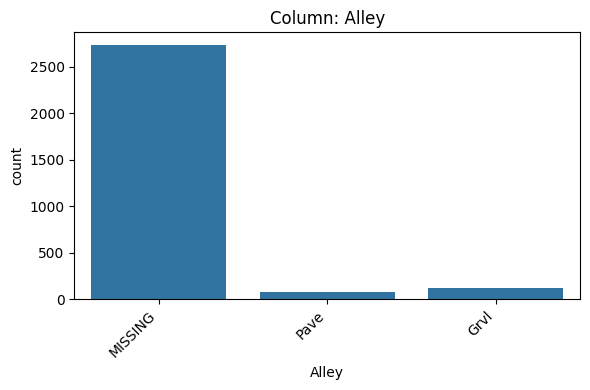

In [47]:
# Test our function on Alley
explore_categorical(df, 'Alley');

/tmp/ipykernel_720/3648891825.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


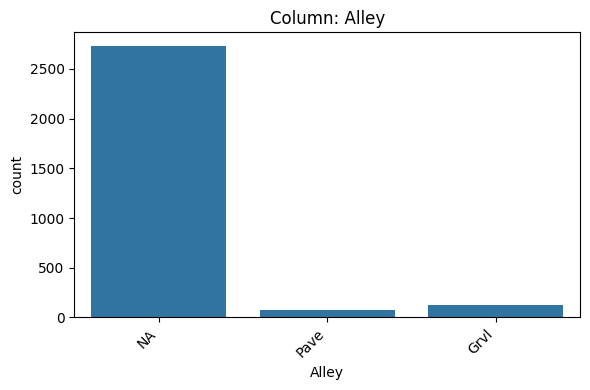

In [48]:
# Testing our function with Alley and placeholder = "NA"
explore_categorical(df, 'Alley', placeholder='NA');

##**Include Keyword Argument for fillna**

In [49]:
def explore_categorical(df, x, fillna=True, placeholder = 'MISSING'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=(6,4))
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")
  fig.tight_layout()

/tmp/ipykernel_720/424091965.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


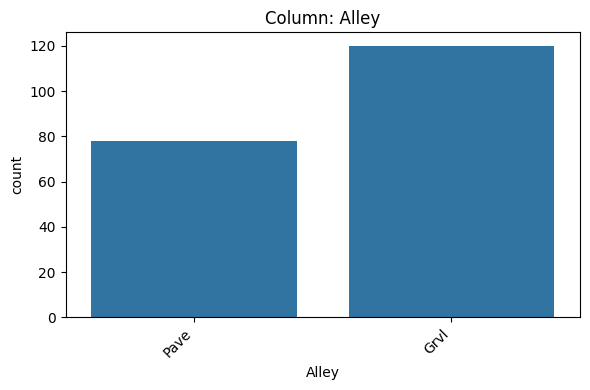

In [50]:
# Test with fillna = False
explore_categorical(df, 'Alley', fillna=False)

##**Include Keyword Argument for figsize and return fig, ax**

In [51]:
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4)):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()

  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")
  fig.tight_layout()
  return fig, ax

/tmp/ipykernel_720/857382625.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


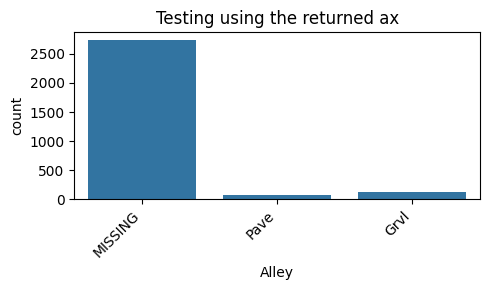

In [52]:
# Test our function with a different fig size and save as fig, ax
fig, ax = explore_categorical(df, "Alley", figsize=(5,3))
# Customize the plot
ax.set_title("Testing using the returned ax");

/tmp/ipykernel_720/857382625.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


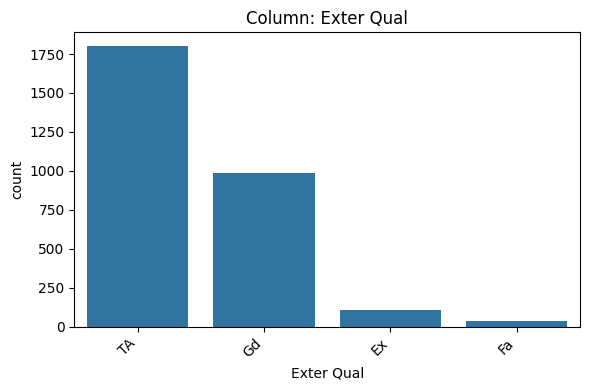

In [53]:
# Test our function on Exter Qual
explore_categorical(df, x='Exter Qual');

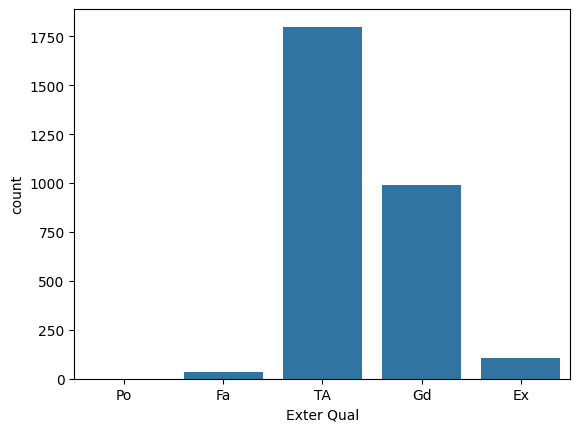

In [54]:
# Saving a list of the possible categories in order
qual_order = ['Po','Fa','TA','Gd','Ex']
# Using the order argument in our countplot
sns.countplot(data=df, x='Exter Qual', order=qual_order);

In [55]:
# checking value_counts
df['Exter Qual'].value_counts(dropna=False)

,count
Exter Qual,
TA,1799
Gd,989
Ex,107
Fa,35


##**Include Keyword Argument for Order**

In [56]:
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()

  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")
  fig.tight_layout()
  return fig, ax

/tmp/ipykernel_720/3217551632.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


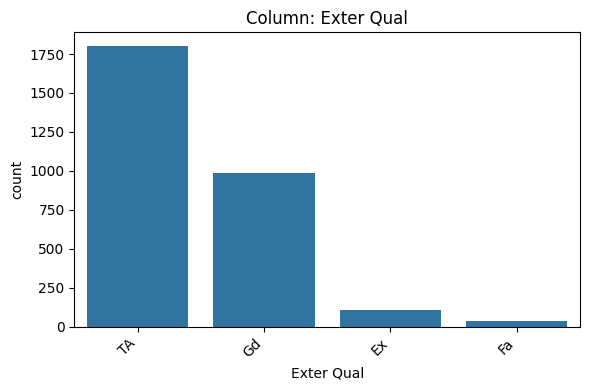

In [57]:
# Checking Exter Qual with default for order (None)
explore_categorical(df, "Exter Qual");



/tmp/ipykernel_720/3217551632.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


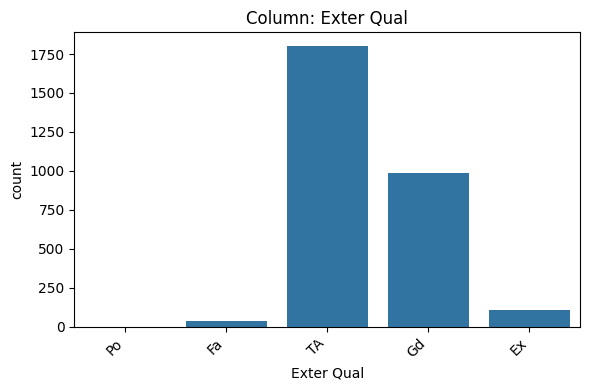

In [58]:
# Checking Exter Qual with order
qual_order = ['Po','Fa','TA','Gd','Ex']
# Use the order argument in our function
explore_categorical(df, "Exter Qual",  order=qual_order);

##**Including Additional Information**

##1) How many missing values are present (both the count and percentage)

In [59]:
# Let's practice on Alley
x = 'Alley'
# Before filling in the NA values with a placeholder, let's get the count and percentage
temp_df = df.copy()
# Save null values counts
null_count = temp_df[x].isna().sum()
# Calculate the percentage of null values
null_perc = null_count/len(temp_df)* 100
# Print the null value info with an f-statement
print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")

- NaN's Found: 2732 (93.24%)


##2) How many different classes are there?

In [60]:
# Print cardinality info
nunique = temp_df[x].nunique()
print(f"- Unique Values: {nunique}")

- Unique Values: 2


##3) What is the most common value, and how often does it occur?

In [61]:
# Get the value counts
val_counts = temp_df[x].value_counts(dropna=False)
val_counts

,count
Alley,
NaN,2732
Grvl,120
Pave,78


In [62]:
# Check the data type of this output
type(val_counts)

pandas.core.series.Series

In [63]:
# Isolate the name of the most common value by using the index
most_common_val = val_counts.index[0]
most_common_val

nan

In [64]:
# Isolate the number of entries having the most common value by using .values
freq = val_counts.values[0]
freq

np.int64(2732)

In [65]:
# Get the percentage of the most common value
perc_most_common =(freq / len(temp_df) *100)
perc_most_common

np.float64(93.24232081911262)

In [66]:
# Get the percentage of the most common value
perc_most_common =(freq / len(temp_df) *100)
perc_most_common

np.float64(93.24232081911262)

In [67]:
# Include a print statement and round the percent
print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

- Most common value: 'nan' occurs 2732 times (93.24%)


In [68]:
# First find value counts of feature
val_counts = temp_df[x].value_counts(dropna=False)
# Define the most common value
most_common_val = val_counts.index[0]
# Define the frequency of the most common value
freq = val_counts.values[0]
# Calculate the percentage of the most common value
perc_most_common = freq / len(temp_df) * 100
# Print the results
print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

- Most common value: 'nan' occurs 2732 times (93.24%)


## 4. Is the feature quasi-constant or constant?

In [69]:
# print message if quasi-constant or constant (most common val more than 98% of data)
if perc_most_common >98:
  print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
else:
  print("- Not constant or quasi-constant.")

- Not constant or quasi-constant.


In [70]:
# Add the print statements to the function
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):

  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax

/tmp/ipykernel_720/965046340.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


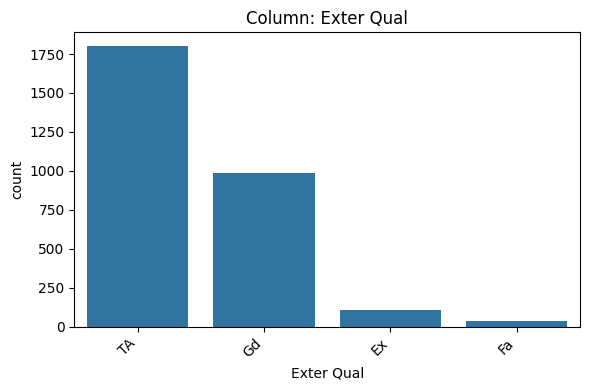

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'TA' occurs 1799 times (61.4%)
- Not constant or quasi-constant.


In [71]:
# Test our function with the print statements
explore_categorical(df, 'Exter Qual');

#**EDA Functions Part 2**

In [72]:
# Declaring required variables
x = "Exter Qual"
y = "SalePrice"

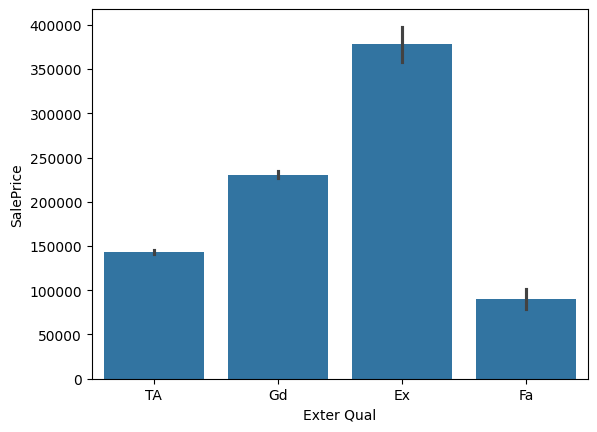

In [73]:
# Default Barplot
sns.barplot(data=df, x=x, y=y);

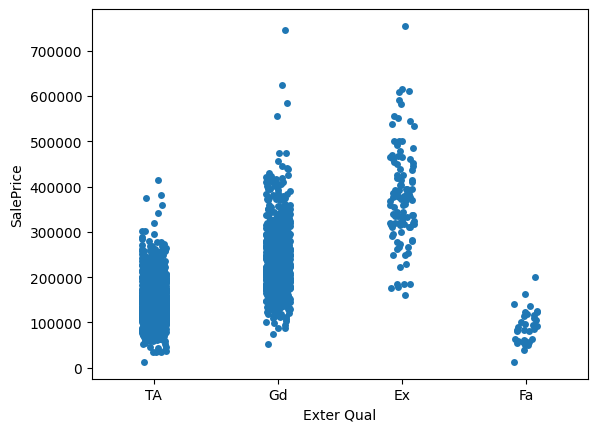

In [74]:
# Default striplot only
sns.stripplot(data =df, x=x, y=y);

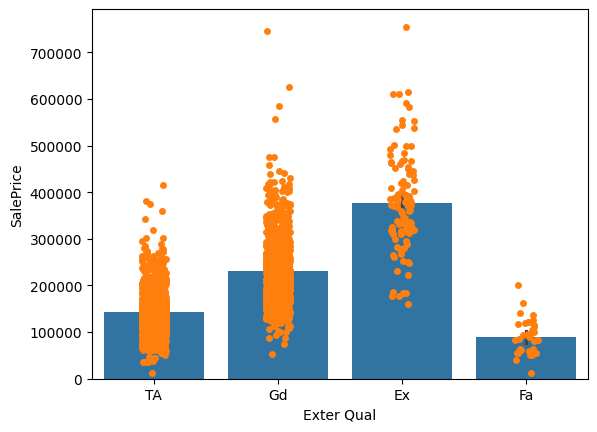

In [75]:
# Striplot and barplot in one plot
# Default Barplot
sns.barplot(data=df, x=x, y=y)
# Default stripplot
sns.stripplot(data =df, x=x, y=y);

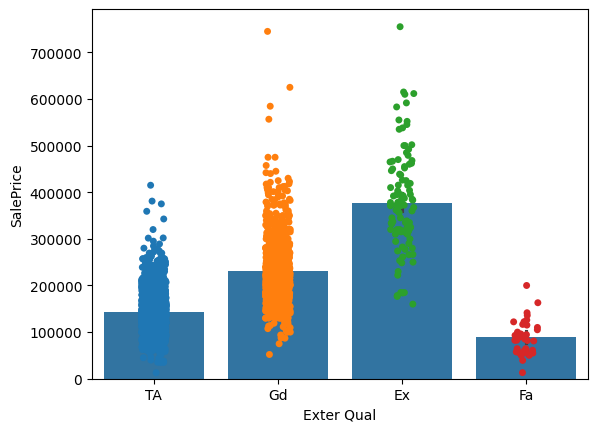

In [76]:
# Let's match the colors of the stripplot and the bar plot
# Striplot and barplot in one plot
# Default Barplot
sns.barplot(data=df, x=x, y=y)
# Include the hue argument for the stripplot
sns.stripplot(data =df, x=x, y=y, hue = x);

In [77]:
# Let's try this code on a feature that has null values
# Declaring required variables
x = "Alley"
y = "SalePrice"

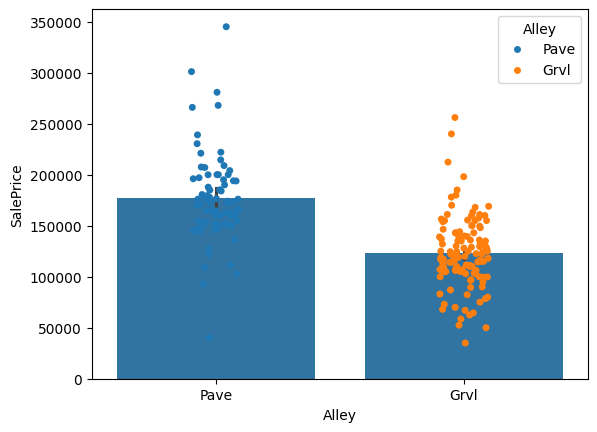

In [78]:
# Stripplot and barplot in one plot
# Default Barplot
sns.barplot(data=df, x=x, y=y)
# Include hue argument for the stripplot
sns.stripplot(data =df, x=x, y=y, hue = x);

##**Method 1) Fill in Missing Values with a Placeholder**

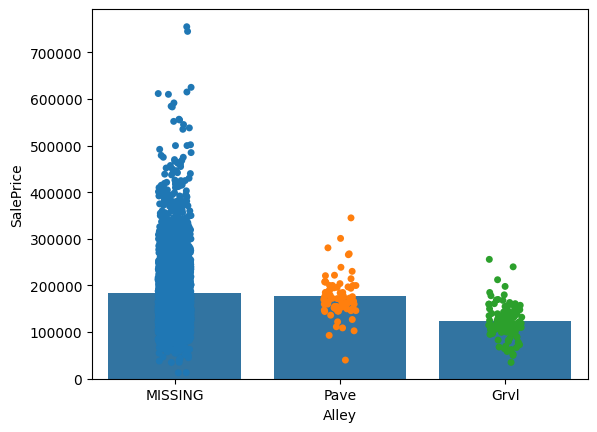

In [79]:
# Make a copy of the dataframe and fillna
temp_df = df.copy()
# Fill missing values with a placeholder
# Define the placeholder
placeholder = 'MISSING'
# fillna with placeholder
temp_df[x] = temp_df[x].fillna(placeholder)
# Striplot and barplot in one plot with placeholder
# Default Barplot
sns.barplot(data=temp_df, x=x, y=y)
# Include hue argument with the stripplot
sns.stripplot(data =temp_df, x=x, y=y, hue = x);

##**Method 2) Dropping Null Values**

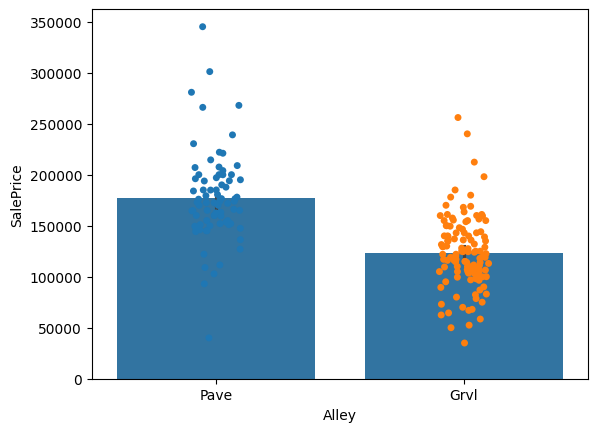

In [80]:
# Make a copy of df to demo dropping null values
demo_df = df.copy()
# Drop nulls before plotting
demo_df = demo_df.dropna(subset=[x])
# Striplot and barplot in one plot with placeholder
# Default Barplot
sns.barplot(data=demo_df, x=x, y=y)
# Include hue argument with the stripplot
sns.stripplot(data =demo_df, x=x, y=y, hue = x);

##**Further Customization**

In [81]:
# We will return to the exter quality for customization to accomodate the ordering
# Declaring required variables
x = "Exter Qual"
y = "SalePrice"

/tmp/ipykernel_12523/784141976.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


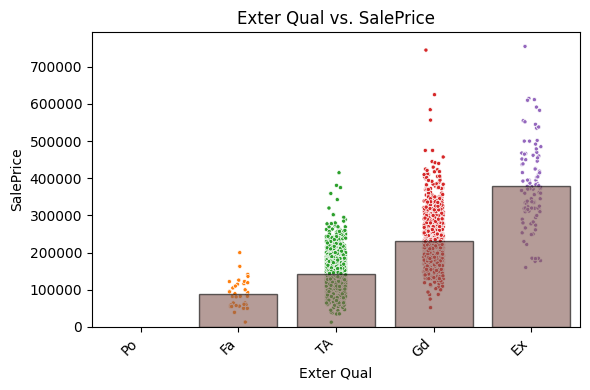

In [ ]:
# Customize the plots
fig, ax = plt.subplots(figsize=(6,4))
# Striplot
sns.stripplot(data=df, x=x, y=y, hue=x, ax=ax,
              order=qual_order, hue_order=qual_order,
              legend=False, edgecolor='white',
              linewidth = 0.5, size=3, zorder=0)
# Barplot
sns.barplot(data=df, x=x, y=y, ax=ax, alpha=0.6, order=qual_order,
            linewidth=1, edgecolor='black', errorbar=None,
            )
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f"{x} vs. {y}")
fig.tight_layout()

In [82]:
# Final version of function
def plot_categorical_vs_target(df, x, y='SalePrice',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

/tmp/ipykernel_720/1069855602.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


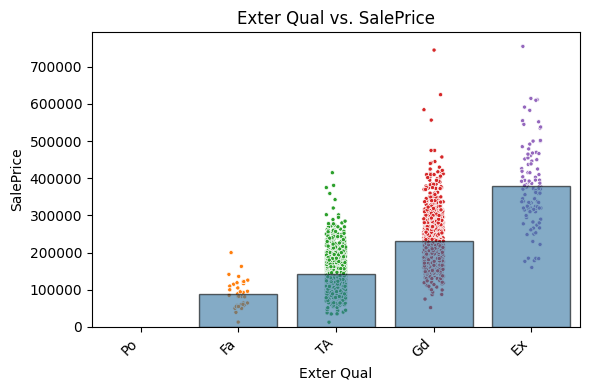

In [83]:
# Test with an order argument
fig, ax = plot_categorical_vs_target(df, x='Exter Qual', fillna=False,
                                  order=qual_order)

/tmp/ipykernel_720/1069855602.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


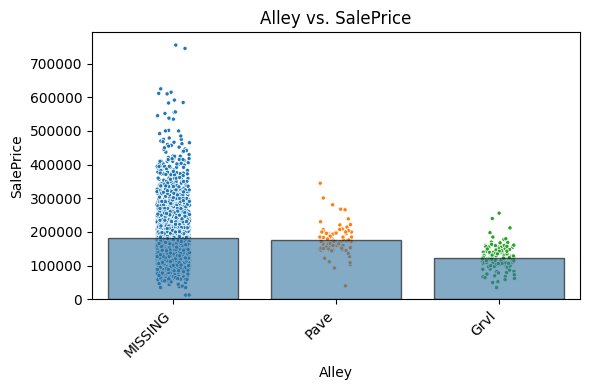

In [84]:
# Test the function
fig, ax = plot_categorical_vs_target(df, x='Alley')

/tmp/ipykernel_720/1069855602.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


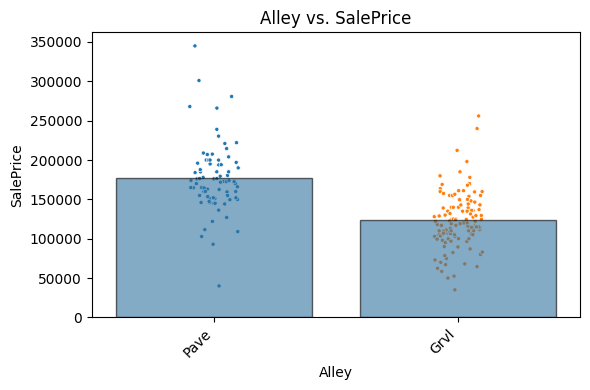

In [85]:
# Test the function without filling in null vlaues
fig, ax = plot_categorical_vs_target(df, x='Alley', fillna=False)

#**EDA Functions Part 3**

##**Constructing explore_numeric**

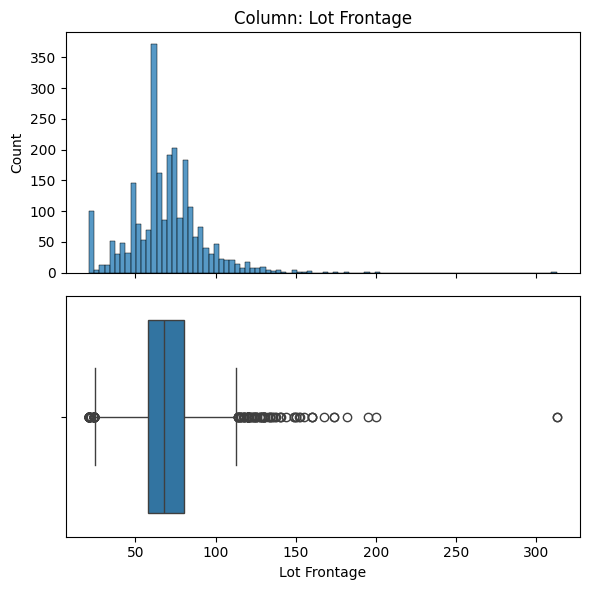

In [86]:
# Specify the x column
x = "Lot Frontage"
# Creating the figure
fig, axes = plt.subplots(nrows=2,  figsize=(6,6), sharex=True)
# Histogram on Top
sns.histplot(data=df, x=x, ax=axes[0])
# Boxplot on Bottom
sns.boxplot(data=df, x=x, ax=axes[1])
axes[0].set_title(f"Column: {x}")
fig.tight_layout()

##**Subplots with different sizes**

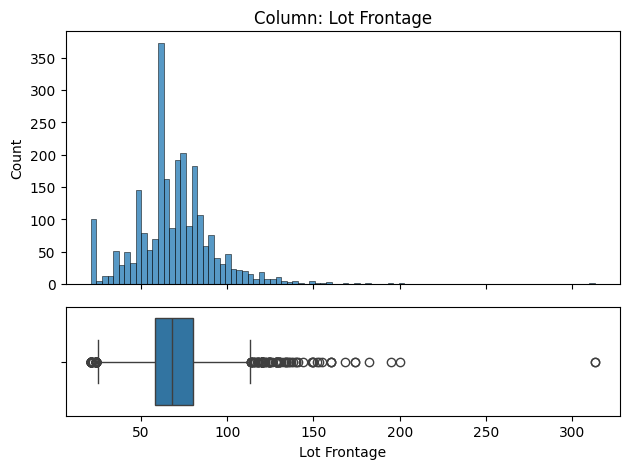

In [87]:
# Customizing subplot heights
gridspec = {"height_ratios":[0.7,0.3]}
fig, axes = plt.subplots(nrows=2,  gridspec_kw=gridspec, sharex=True)
# Histogram on Top
sns.histplot(data=df, x=x, ax=axes[0])
# Boxplot on Bottom
sns.boxplot(data=df, x=x, ax=axes[1])
axes[0].set_title(f"Column: {x}")
fig.tight_layout()

In [88]:
# Print message with info on the count and % of null values
null_count = df[x].isna().sum()
null_perc = (null_count / len(df)) * 100
print(f"- NaN's Found: {null_count} ({null_perc}%)")





- NaN's Found: 490 (16.723549488054605%)


##**Define Function**

In [89]:
def explore_numeric(df, x, figsize=(6,5) ):
  # Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])
  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])
  ## Adding a title
  axes[0].set_title(f"Column: {x}")
  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  ## Print message with info on the count and % of null values
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")

##**Test the function**

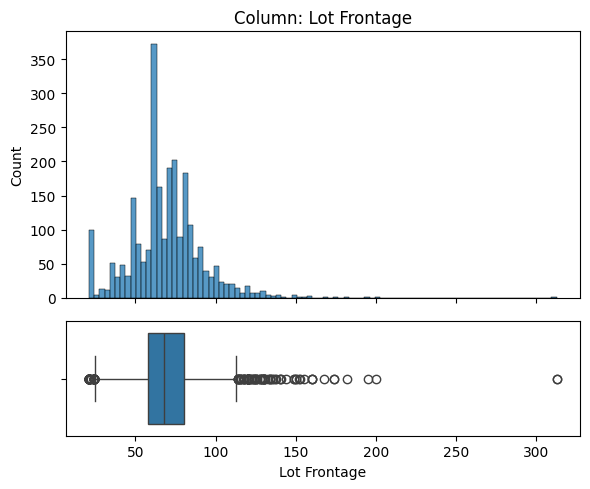

- NaN's Found: 490 (16.72%)


In [90]:
# Test the function
explore_numeric(df, "Lot Frontage")

#**Constructing plot_numeric_vs_target**

In [91]:
# Declaring required variables
x = 'Lot Frontage'
y = "SalePrice"
# calculating correlation
corr = df[[x,y]].corr().round(2)
corr

,Lot Frontage,SalePrice
Lot Frontage,1.00,0.36
SalePrice,0.36,1.00


In [92]:
# To get the value for x vs y correlation:
r = corr.loc[x,y]
r

np.float64(0.36)

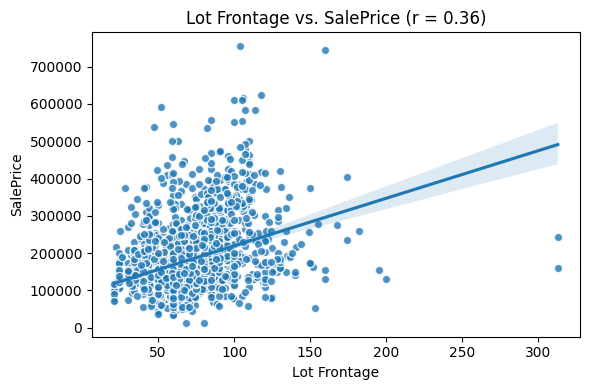

In [93]:
# Plot the data
fig, ax = plt.subplots(figsize=(6,4))
scatter_kws={'ec':'white','linewidths': 1,'alpha':0.8}
sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)
# Add the title with the correlation
ax.set_title(f"{x} vs. {y} (r = {r})")
fig.tight_layout()


##**Define the function**

In [94]:
def plot_numeric_vs_target(df, x, y='SalePrice', figsize=(6,4)):
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)
  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})")
  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax

##**Test the Function**

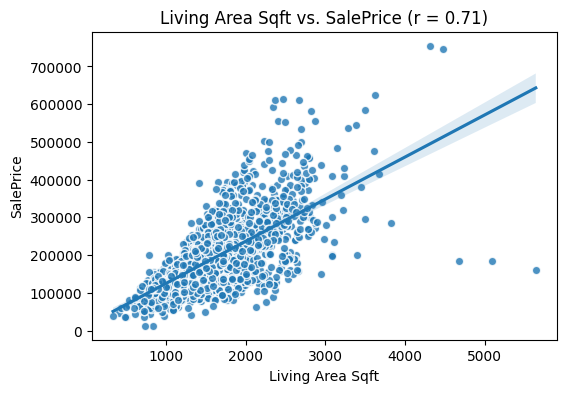

In [95]:
# Test the function with Living Area Sqft
fig, ax = plot_numeric_vs_target(df, "Living Area Sqft")

##**Add kwargs argument to the custom function**

In [96]:
# Add **kwargs as keyword when defining function
# Include **kwargs in the sns.regplot() within the function

def plot_numeric_vs_target(df, x, y='SalePrice', figsize=(6,4), **kwargs): # kwargs for sns.regplot
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})")
  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax

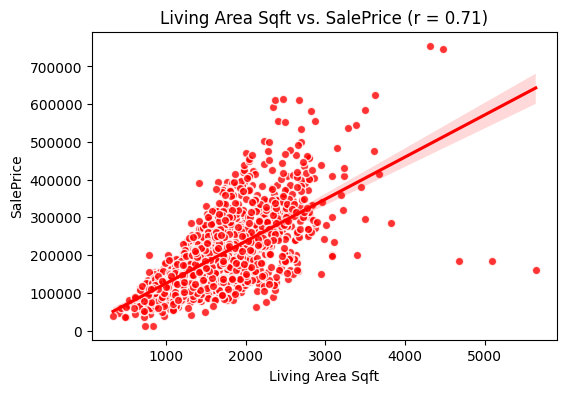

In [97]:
# Test the function with a kwarg from the regplot function
fig, ax = plot_numeric_vs_target(df, "Living Area Sqft", color = 'red')

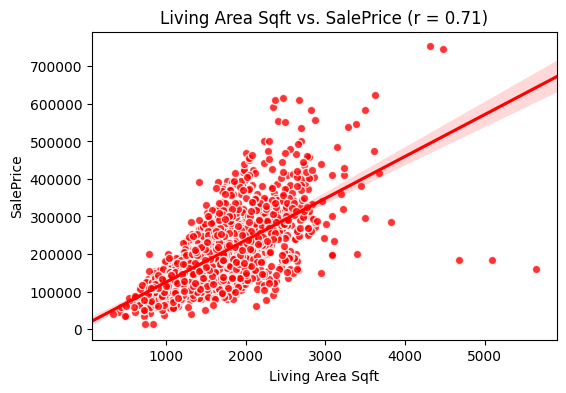

In [98]:
# Test the function with two kwargs from the regplot function
fig, ax = plot_numeric_vs_target(df, "Living Area Sqft", color = 'red', truncate = False)

#**Our 4 functions**

#**1-explore_categorical**

In [99]:
# Add the print statements to the function
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):

  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax

👉 شو بتعمل؟

بترسم countplot لعمود categorical
بتعالج القيم الفارغة (تحط "MISSING" إذا بدك)
وبتطبع معلومات مهمة عن العمود

📌 باختصار:
👉 “بتعرض توزيع القيم + معلومات (NaN، عدد القيم، الأكثر تكرارًا)”

#**2-plot_categorical_vs_target**

In [100]:
# Final version of function
def plot_categorical_vs_target(df, x, y='SalePrice',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

👉 شو بتعمل؟

بترسم رسمتين:
Histogram (فوق)
Boxplot (تحت)
عشان تفهم توزيع البيانات
وبتطبع عدد القيم الفارغة

📌 باختصار:
👉 “بتعرض شكل توزيع الأرقام + القيم الفارغة”

#**3-explore_numerical**

In [101]:
def explore_numeric(df, x, figsize=(6,5) ):
  # Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])
  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])
  ## Adding a title
  axes[0].set_title(f"Column: {x}")
  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  ## Print message with info on the count and % of null values
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")

نفس explore_numeric بالزبط → ما في فرق

##**4-plot_numeric_vs_target**

In [102]:
# Add **kwargs as keyword when defining function
# Include **kwargs in the sns.regplot() within the function

def plot_numeric_vs_target(df, x, y='SalePrice', figsize=(6,4), **kwargs): # kwargs for sns.regplot
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})")
  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax

👉 شو بتعمل؟

بترسم scatter + خط اتجاه (regplot)
بتحسب correlation (r) بين x و y
وبتحطه بالعنوان

📌 باختصار:
👉 “بتوضح العلاقة بين متغيرين رقميين + قوة العلاقة”

**categorical ➜ count + info**

**numeric ➜ distribution (hist + box)**

**numeric vs target ➜ relationship + correlation**

#**Inspecting Features**

##**Demonstration of Feature Inspection Workflow**

##**Inspecting: Utilities**

**1) Univariate Viz**

In [119]:
# Confirming the dtype to select correct EDA function
feature = "Utilities"
df[feature].dtype

dtype('O')

/tmp/ipykernel_720/965046340.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


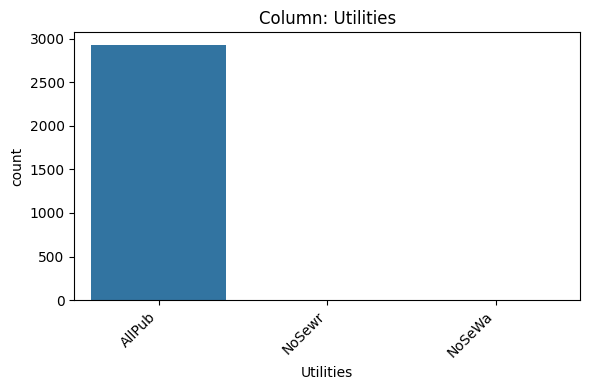

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'AllPub' occurs 2927 times (99.9%)

- [!] Warning: 'Utilities' is a constant or quasi-constant feature and should be dropped.


In [120]:
# Calling our custom EDA function
explore_categorical(df, feature);

**2)Feature Observations**

💣 النتيجة المتوقعة لهالمثال

غالبًا Utilities:
👉 معظم القيم = AllPub

يعني:

تقريبًا كل البيانات نفس الشي 😐
➡️ Quasi-constant
🚨 القرار النهائي

👉 نحذفه ❌
لأنه:

ما بيفرق بين البيوت
ما بيساعد المودل

##**3) Multivariate Viz**

/tmp/ipykernel_720/1069855602.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


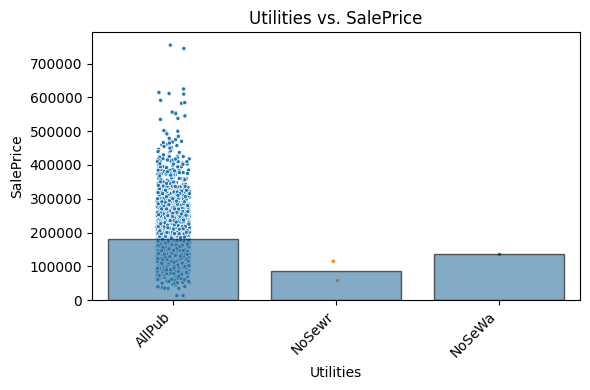

In [121]:
# Calling our custom EDA function
plot_categorical_vs_target(df, feature);

**Feature vs. Target Observations**

💥 الخلاصة

👉 إحنا توقعنا إنه مهم ✔
👉 بس البيانات ما أثبتت ❌
👉
"مش كل شي منطقي = فعلاً مفيد بالمودل"

**Inspecting: Garage Qual**

In [122]:
# Confirming the dtype to select correct EDA function
feature = "Garage Qual"
df[feature].dtype

dtype('O')

/tmp/ipykernel_720/965046340.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


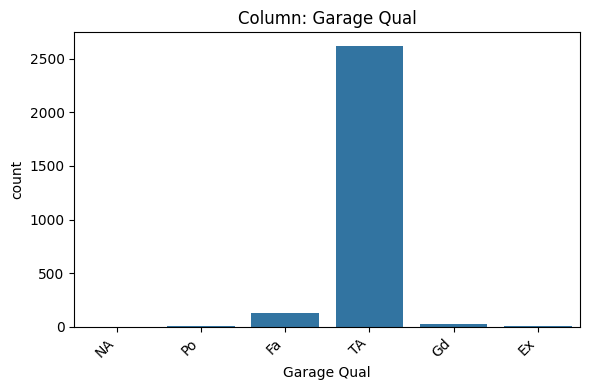

- NaN's Found: 159 (5.43%)
- Unique Values: 6
- Most common value: 'TA' occurs 2615 times (89.25%)
- Not constant or quasi-constant.


In [123]:
# Define the order
garage_qual_order = ["NA",'Po', 'Fa', 'TA', 'Gd', 'Ex']
# Using explore_categorical based on dtype
explore_categorical(df, feature, order=garage_qual_order);

**Feature vs. Target Observations**

📌 Garage Qual – Feature Observations

Type: Categorical (Ordinal)

Null Values: 159 (5.43%)

Handling Nulls: نعوضهم بـ "NA" (يعني No Garage)

Constant / Quasi-constant: ❌ لا

(أعلى قيمة ≈ 89% < 98%)

Cardinality: منخفضة (6 قيم) ✔

Available before target: ✔ نعم

Business Logic: ✔ مهم

(صاحب البيت يقدر يتحكم بجودة الكراج)

🎯 الخلاصة

👉 Feature مفيد ✔

لا نحذفه

/tmp/ipykernel_720/1069855602.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


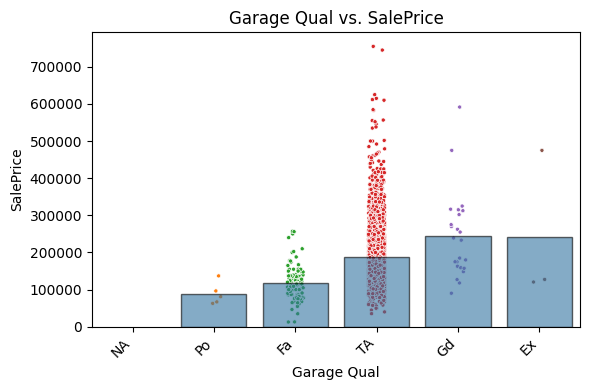

In [124]:
# Call custom function
plot_categorical_vs_target(df, feature, order=garage_qual_order);

**Feature vs. Target Observations**

📊 Garage Qual – Multivariate Observations

Expected (Business): ✔ نعم

(جودة الكراج المفروض تأثر على السعر)

Actual (From Data): ⚠️ ممكن

(في اتجاه زيادة من NA → Gd)
Observation:

👉 متوسط السعر يزيد مع الجودة

لكن:

👉 فئة TA فيها spread كبير (أسعار متفاوتة كثير)

🎯 الخلاصة

👉 Feature مفيد لكن مش قوي جدًا

(فيه علاقة بس مش واضحة 100%)

##**Inspecting: Lot Frontage**

**1) Univariate Viz**

In [108]:
# Confirming the dtype to select correct EDA function
feature = "Lot Frontage"
df[feature].dtype

dtype('float64')

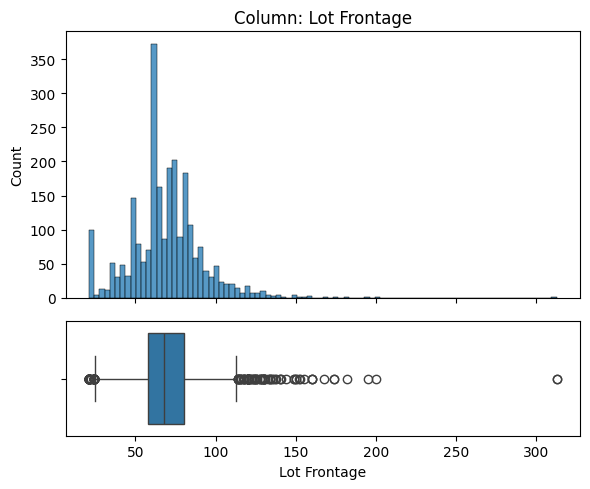

- NaN's Found: 490 (16.72%)


In [109]:
# Calling custom EDA function for numeric
explore_numeric(df, feature);

**2) Feature Observations**

📌 Lot Frontage – Feature Observations

Type: Numeric

Null Values: 490 (16.72%) ⚠️

Handling Nulls:

👉 لازم نتحقق:

هل missing عشوائي؟

أو لأنه البيت ما عنده lot؟

📌 احتمال:

missing لها معنى (مش random)

Constant / Quasi-constant: ❌ لا

Cardinality: ❌ غير مهم (لأنه numeric)

Available before target: ✔ نعم

Business Logic: ✔ مهم

(طول الواجهة ممكن يأثر على السعر)

🎯 الخلاصة

👉 Feature مهم ✔

لكن:

⚠️ لازم ندرس الـ missing قبل ما نقرر كيف نعالجها

⚡ سطر تحف

**الفكرة العامة**

**👉 بدنا نعرف:**

**ليش في missing values؟**

**هل لأنها 0؟**

**ولا عشوائية؟**

In [125]:
# Checking for lowest value for lot frontage
df['Lot Frontage'].min()

21.0

**🔹 1) نتحقق من أصغر قيمة**

In [126]:
# Define columns to inspect related to lot
lot_columns = ['Lot Frontage', 'Lot Area']

**🔹 2) نحدد الأعمدة المرتبطة**

In [127]:
# Save filter of null lot frontages
filter_null_lot_frontage = df['Lot Frontage'].isna()
filter_null_lot_frontage.sum()

np.int64(490)

**🔹3) نعمل فلتر للقيم الفارغة**

**نعد كم في missing**

In [128]:
# Filter the lot columsn for rows missing lot frontage
check_lots = df.loc[filter_null_lot_frontage, lot_columns]
check_lots

,Lot Frontage,Lot Area
PID,,
534275170,NaN,12772
534127170,NaN,9156
528292080,NaN,12104
534278150,NaN,14357
528280100,NaN,11214
...,...,...
914476380,NaN,9947
906230020,NaN,7939
905300020,NaN,10200


**🔹 4) نشوف هاي الصفوف فقط**

In [129]:
# Obtain null value counts for the lot columns
check_lots.isna().sum()

,0
Lot Frontage,490
Lot Area,0


**🔹5) نعد الـ null داخلهم**

أهم استنتاج

👉 لو السبب:
"البيت ما عنده أرض"

➡️ لازم Lot Area كمان تكون null ❗

لكن:
❌ Lot Area موجودة

🎯 النتيجة

👉 إذًا:

missing values عشوائية (Random)
******************
الخلاصة تحفظيها:

👉
**إذا missing مش مرتبطة بعمود ثاني →**

**➡️ Missing at random → نستخدم mean أو median**

**Feature Observations (continued)**

📌 Lot Frontage – Feature Observations (Final)

Type: Numeric

Null Values: 490 (16.72%) ⚠️

Handling Nulls:

👉 Missing at random

👉 نعوض بـ mean أو median

Constant / Quasi-constant: ❌ لا

Cardinality: ❌ غير مهم (numeric)

Available before target: ✔ نعم

Business Logic: ⚠️

👉 مش بإيد صاحب البيت

لكن:

👉 مفيد للتنبؤ بالسعر

🎯 الخلاصة

👉 Feature مفيد ✔

لكن يحتاج imputation للـ missing

##**3) Multivariate Viz**

/tmp/ipykernel_720/1069855602.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


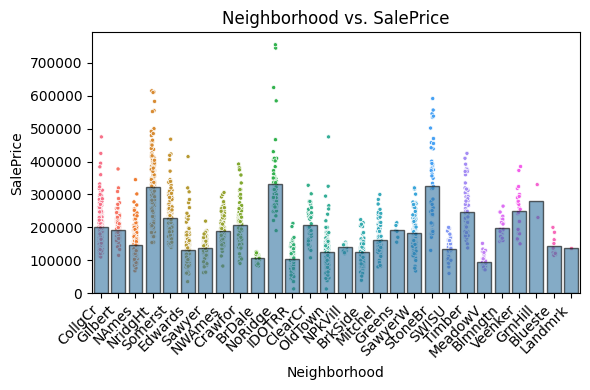

In [134]:
# Call custom function
plot_categorical_vs_target(df, feature);

**4) Feature vs. Target Observations**

Feature يظهر علاقة إيجابية بالـ target (r=0.36)، أي كلما زادت قيمة الـ feature زاد السعر، لكن هناك بعض القيم الشاذة التي قد تؤثر على اتجاه العلاقة.

##**Inspecting: Neighborhood**

**1) Univariate Viz**

In [131]:
# Confirming the dtype to select correct EDA function
feature = "Neighborhood"
df[feature].dtype

dtype('O')

/tmp/ipykernel_720/965046340.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


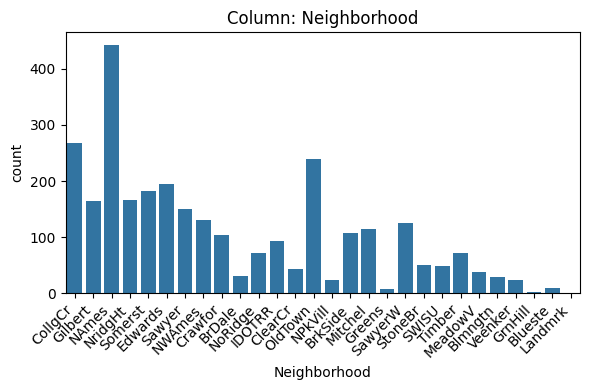

- NaN's Found: 0 (0.0%)
- Unique Values: 28
- Most common value: 'NAmes' occurs 443 times (15.12%)
- Not constant or quasi-constant.


In [132]:
# Calling custom function
explore_categorical(df, feature);

**2) Feature Observations**

Neighborhood ميزة تصنيفية (Categorical) بدون قيم مفقودة، غير ثابتة، تحتوي على 28 فئة (High cardinality) مما قد يسبب صعوبة في النمذجة. هذه الميزة معروفة قبل معرفة الهدف ولا يمكن تغييرها من قبل المالك، لذا قد يتم استبعادها من التحليل.

##**3) Multivariate Viz**

**2) Feature Observations**

/tmp/ipykernel_720/1069855602.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


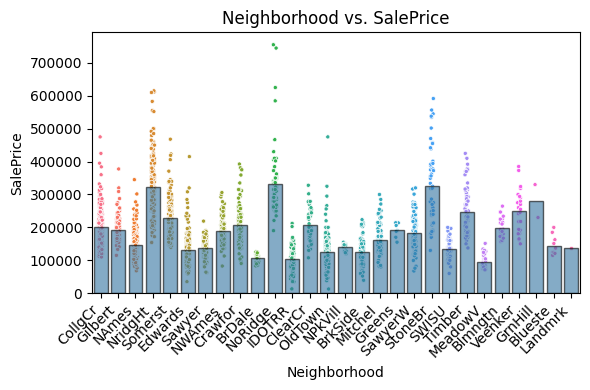

In [133]:
# Calling custom function
plot_categorical_vs_target(df, feature);

**4) Feature vs. Target Observations**

Neighborhood يؤثر على قيمة المنزل، حيث تختلف المتوسطات ونطاقات الأسعار بين الأحياء، مما يجعله ميزة ذات قدرة على التنبؤ بالهدف